# Titanic Experiment Log Summary

This notebook gives a quick, readable overview of the experiment history.

Use it when you want a simple explanation of what improved across runs without using widgets.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

LOG_PATH = Path("../outputs/experiment_log.csv")
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
def load_experiment_log(path=LOG_PATH):
    if not path.exists():
        return pd.DataFrame()

    log_df = pd.read_csv(path)
    if log_df.empty:
        return log_df

    log_df["timestamp_utc"] = pd.to_datetime(log_df["timestamp_utc"], utc=True, errors="coerce")
    log_df = log_df.dropna(subset=["timestamp_utc"]).sort_values("timestamp_utc").reset_index(drop=True)
    log_df["run_number"] = log_df.index + 1
    return log_df


log_df = load_experiment_log()

if log_df.empty:
    print("No experiment log found yet. Run main.py first.")
else:
    latest = log_df.iloc[-1]
    summary = pd.DataFrame([
        {
            "Latest run": int(latest["run_number"]),
            "Timestamp UTC": latest["timestamp_utc"].strftime("%Y-%m-%d %H:%M UTC"),
            "Best baseline model": latest["best_baseline_model"],
            "Best engineered model": latest["best_engineered_model"],
            "Top delta model": latest["top_delta_model"],
            "Top F1 delta": round(float(latest["top_f1_delta"]), 4),
            "Mean F1 delta": round(float(latest["mean_f1_delta"]), 4),
        }
    ])

    display(summary)


,Latest run,Timestamp UTC,Best baseline model,Best engineered model,Top delta model,Top F1 delta,Mean F1 delta
0,3,2026-04-18 18:15 UTC,RandomForest,LogisticRegression,LogisticRegression,0.0786,0.0381


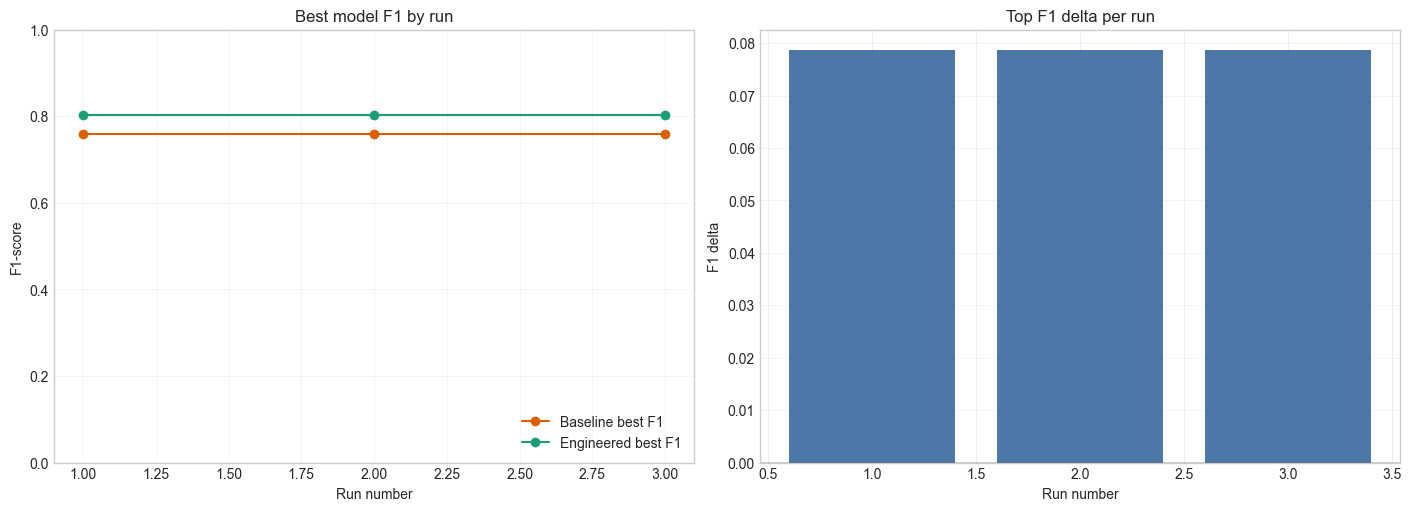

In [3]:
if not log_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    ax = axes[0]
    ax.plot(log_df["run_number"], log_df["best_baseline_f1"], marker="o", label="Baseline best F1", color="#d95f02")
    ax.plot(log_df["run_number"], log_df["best_engineered_f1"], marker="o", label="Engineered best F1", color="#1b9e77")
    ax.set_title("Best model F1 by run")
    ax.set_xlabel("Run number")
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")

    ax = axes[1]
    ax.bar(log_df["run_number"], log_df["top_f1_delta"], color="#4c78a8")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Top F1 delta per run")
    ax.set_xlabel("Run number")
    ax.set_ylabel("F1 delta")
    ax.grid(True, axis="y", alpha=0.3)

    plt.show()


## Key takeaways

- The project starts with a Titanic survival prediction task.
- Baseline preprocessing becomes stronger with `FamilySize`, `IsAlone`, and `Title`.
- Logistic Regression often benefits the most from the engineered features.
- The experiment log makes it easy to compare runs over time.